# Cu Nanoparticles formation in LDPE

## Set_up()

In [180]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
import matplotlib.ticker as mticker

✓ Workspace ready


## Data

In [44]:
poni_saxs = r"E:\Nps Cu\IHSC 1872\SAXS_1p4m_12keV.poni"
ai_saxs = pyFAI.load(poni_saxs)

poni_waxs = r"E:\Nps Cu\IHSC 1872\WAXS_1p4m_12keV.poni"
ai_waxs = pyFAI.load(poni_waxs)

mask_saxs = r"E:\Nps Cu\IHSC 1872\MASK_SAXS_1p4m_12keV.edf"
img_mask_saxs = fabio.open(mask_saxs).data

mask_waxs = r"E:\Nps Cu\IHSC 1872\MASK_WAXS_1p4m_12keV.edf"
img_mask_waxs = fabio.open(mask_waxs).data

##### Cu 0.5%

In [2]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_aftertrans\CuPE_0_5perc_1_4m_aftertrans_RT_measurement'
Cu_05_after = BM26_experiment(path)

##### Cu 3%

In [3]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_aftertrans\CuPE_3perc_1_4m_aftertrans_RT_measurement'
Cu_3_after = BM26_experiment(path)

## Functions

In [4]:
def Guinier(q, I_0, R_g):
    return I_0 * np.exp(-q ** 2 * R_g ** 2 / 3)

def norm(data):
    q = data['q']
    I = data['I']
    
    left = 28
    right = 28.8
    Q_norm = np.trapz(I[(q>left)*(q<right)], x = q[(q>left)*(q<right)])
    
    data['I']/=Q_norm

def norm_saxs(q, I):
    I /= np.mean(I[(q>3)*(q<4)])

# Analysis

In [351]:
def norm_saxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>3)*(q<4)])
    #return q, I

def norm_waxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>20)*(q<20.5)])
    #return q, I

##### style

In [6]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 20
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.tt'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

## 3% Results

### Fig 1a

In [439]:
q, I_3_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q, I_3_heat)
print(len(I_3_heat))

89


In [440]:
q, I_3_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q, I_3_iso)
print(len(I_3_iso))

60


In [485]:
q, I_05_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q, I_05_heat)
print(len(I_05_heat))

88


In [486]:
q, I_05_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q, I_05_iso)
print(len(I_05_iso))

66


In [218]:
Time_3_iso = Cu_3_iso.get_Time_profile()
Temp_3_iso = Cu_3_iso.get_T_profile()
Time_3_heat = Cu_3_heat.get_Time_profile()
Temp_3_heat = Cu_3_heat.get_T_profile()

Found 60 EDF files in SAXS
Found 89 EDF files in SAXS


In [398]:
Time_05_iso = Cu_05_iso.get_Time_profile()
Temp_05_iso = Cu_05_iso.get_T_profile()
Time_05_heat = Cu_05_heat.get_Time_profile()
Temp_05_heat = Cu_05_heat.get_T_profile()

Found 66 EDF files in SAXS
Found 88 EDF files in SAXS


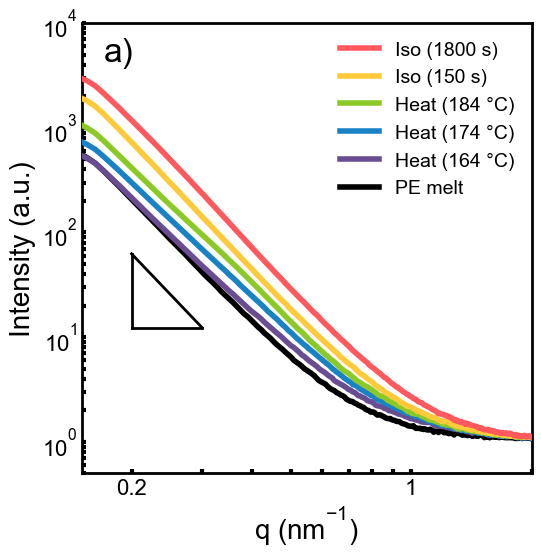

In [222]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 0

ax.plot(q, I_3_iso[59] -  K * I_3_heat[45], linewidth=4, label='Iso (1800 s)', color='#ff595e', zorder=10)
ax.plot(q, I_3_iso[5] -  K * I_3_heat[45], linewidth=4, label='Iso (150 s)', color='#ffca3a', zorder=9)

ax.plot(q, I_3_heat[80] - K * I_3_heat[45], linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, I_3_heat[75] - K * I_3_heat[45], linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, I_3_heat[70] - K * I_3_heat[45], linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=6)

ax.plot(q, I_3_heat[45] - K * I_3_heat[45] , linewidth=4, label='PE melt', color='black', zorder=1)


lnsp = np.linspace(0.2, 0.3, 1000)
plt.plot(lnsp, lnsp**-4 / 10, color='black', linewidth=2)
plt.plot(lnsp, np.ones(1000) * min(lnsp**-4 / 10), color='black', linewidth=2)
plt.plot(np.ones(1000)*lnsp[0], lnsp**-4 / 10, color='black',linewidth=2)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.15, 2)
ax.set_ylim(0.5, 1e4)
ax.set_xticks([0.2, 1])
ax.set_xticklabels(['0.2', '1'])

# Легенда
ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'a)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'E:\Nps Cu\Figures\Fig1_a.png', dpi=300, bbox_inches='tight', transparent=True)



### Fig 1b

In [382]:
q, I_3_heat = Cu_3_heat.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q, I_3_heat)

In [383]:
q, I_05_heat = Cu_05_heat.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q, I_05_heat)

In [384]:
q, I_3_iso = Cu_3_iso.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q, I_3_iso)

In [385]:
q, I_05_iso = Cu_05_iso.integrate1d_WAXS(ai_waxs, 1000, mask=img_mask_waxs, unit='q_nm^-1')
norm_waxs(q, I_05_iso)

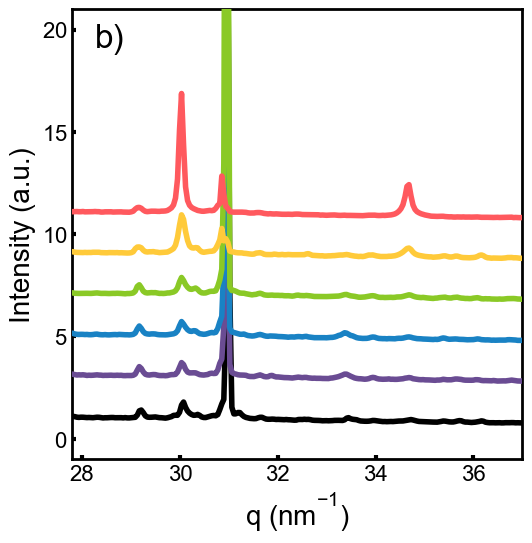

In [367]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 2

ax.plot(q, I_3_iso[59]  + 5 * K, linewidth=4, label='Iso (1800 s)', color='#ff595e', zorder=10)
p = 553
#plt.scatter(q[p], I_3_iso[59][p] + 5 * K, marker = 'x', s=200, color='black', zorder=100)

ax.plot(q, I_3_iso[5]  + 4 * K, linewidth=4, label='Iso (150 s)', color='#ffca3a', zorder=9)

ax.plot(q, I_3_heat[80]  + 3 * K, linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, I_3_heat[75] + 2 * K, linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, I_3_heat[70] + K, linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=5)

ax.plot(q, I_3_heat[50] , linewidth=4, label='PE melt', color='black', zorder=1)


lnsp = np.linspace(0.2, 0.3, 1000)
plt.plot(lnsp, lnsp**-4 / 10, color='black', linewidth=2)
plt.plot(lnsp, np.ones(1000) * min(lnsp**-4 / 10), color='black', linewidth=2)
plt.plot(np.ones(1000)*lnsp[0], lnsp**-4 / 10, color='black',linewidth=2)

ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(27.8, 37)
ax.set_ylim(-1, 21)
ax.set_yticks([0, 5, 10, 15, 20])
#ax.set_xticklabels(['0.2', '1'])

# Легенда
#ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'b)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left', zorder=100)

ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((-2, 3)) 
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.savefig(r'E:\Nps Cu\Figures\Fig1_b.png', dpi=300, bbox_inches='tight', transparent=True)

### Fig 3a

In [502]:
def Invariant(q, I):
    l = 0.15
    r = 1.5
    x = q[(q>l)*(q<r)]
    y = I[(q>l)*(q<r)]
    return np.trapz(y*x**2, x=x)

In [507]:
Invariant_3 = []

for i in range(89):
    Invariant_3.append(Invariant(q, I_3_heat[i]))

for i in range(60):
    Invariant_3.append(Invariant(q, I_3_iso[i]))

Invariant_05 = []

for i in range(88):
    Invariant_05.append(Invariant(q, I_05_heat[i]))

for i in range(66):
    Invariant_05.append(Invariant(q, I_05_iso[i])) 

Invariant_05 -= min(Invariant_05)
Invariant_3 -= min(Invariant_3)

C:\Users\LabPC\AppData\Local\Temp\ipykernel_15404\1147408303.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y*x**2, x=x)


In [535]:
np.array([1,2,3,4,5,6,7])[::2]

array([1, 3, 5, 7])

In [394]:
I_111_3 = []

for i in range(89):
    I_111_3.append(I_3_heat[i][553])

for i in range(60):
    I_111_3.append(I_3_iso[i][553])    

I_111_05 = []

for i in range(88):
    I_111_05.append(I_05_heat[i][552])

for i in range(66):
    I_111_05.append(I_05_iso[i][552])    

Text(0.03, 0.97, 'a)')

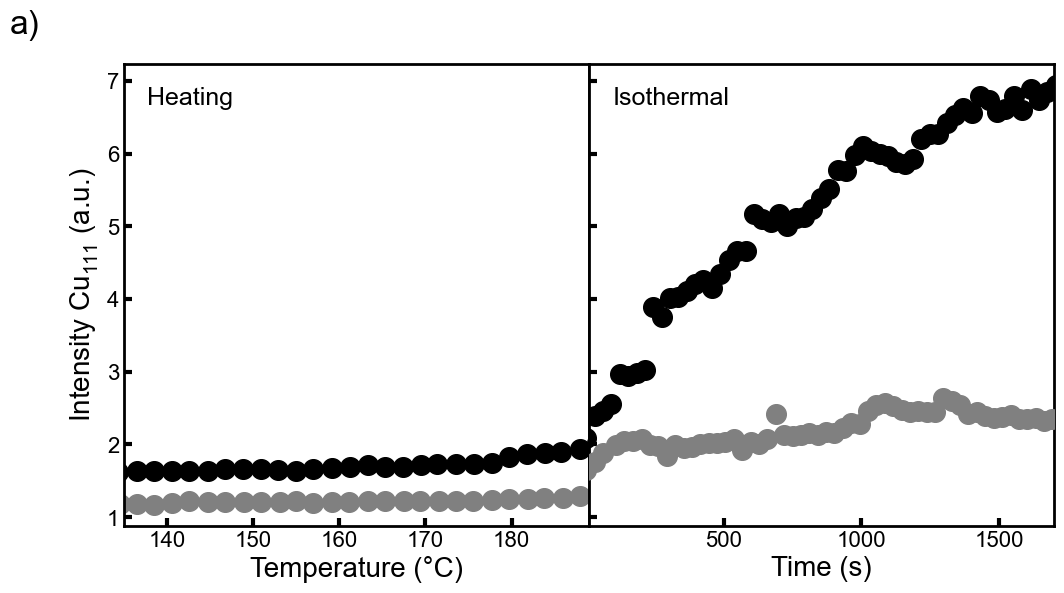

In [537]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# Создаем фигуру с двумя subplots, которые делят одну ось Y
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

K = 150
s = 200
# График нагрева (левая панель)
ax1.scatter(Temp_3_heat, I_111_3[:89], s=s, color='black', zorder=0)
ax1.scatter(Temp_05_heat, I_111_05[:88], s=s, color='grey', zorder=0)
ax1.set_xlabel('Temperature (°C)', fontsize=20, fontfamily='Arial')
ax1.set_xlim(135, 189)
ax1.text(0.05, 0.95, 'Heating', transform=ax1.transAxes, fontsize=18, 
         fontfamily='Arial', verticalalignment='top')

# График изотермы (правая панель)
ax2.scatter(Time_3_iso, I_111_3[89:], s=s, color='black', zorder=10)
ax2.scatter(Time_05_iso, I_111_05[88:], s=s, color='grey', zorder=10)
ax2.set_xlabel('Time (s)', fontsize=20, fontfamily='Arial')
ax2.set_xlim(10, 1700)
ax2.text(0.05, 0.95, 'Isothermal', transform=ax2.transAxes, fontsize=18,
         fontfamily='Arial', verticalalignment='top')

# Общая ось Y (только для левого графика)
ax1.set_ylabel('Intensity Cu$_{111}$ (a.u.)', fontsize=20, fontfamily='Arial')

# Утолщенные рамки для обоих графиков
for ax in [ax1, ax2]:
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    ax.tick_params(axis="both", which='both', direction="in", width=3, length=6, labelsize=16)
    
    # Шрифты для подписей
    for tick in ax.get_xticklabels():
        tick.set_fontfamily('Arial')
    for tick in ax.get_yticklabels():
        tick.set_fontfamily('Arial')

# # Добавляем вертикальную линию перехода (опционально)
# ax1.axvline(x=180, color='gray', linestyle='--', linewidth=2, alpha=0.7)
# ax1.text(182, 700, '180°C', fontsize=14, fontfamily='Arial')

# Настройка позиции
plt.subplots_adjust(wspace=0.0)  # уменьшаем расстояние между графиками

# Добавляем общую подпись (опционально)
fig.text(0.03, 0.97, 'a)', fontsize=24, fontfamily='Arial', 
         verticalalignment='top', horizontalalignment='left')

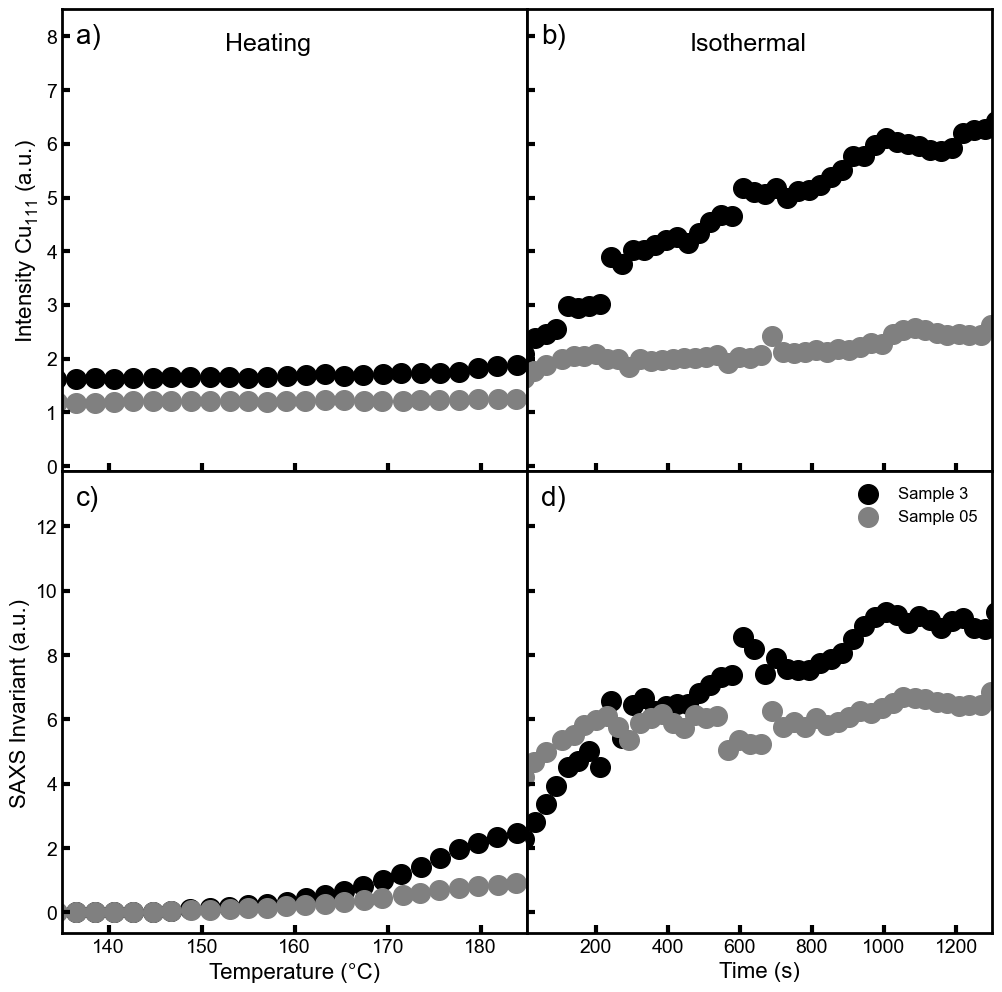

In [540]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# Создаем фигуру с 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 12), 
                        sharex='col',  # общие оси X в столбцах
                        sharey='row',  # общие оси Y в строках
                        gridspec_kw={'hspace': 0.00, 'wspace': 0.00})

# Извлекаем оси для удобства
(ax1, ax2), (ax3, ax4) = axs

K = 150
s = 200

# --- ВЕРХНИЙ РЯД: Интенсивность Cu111 ---

# График нагрева (левая верхняя панель)
ax1.scatter(Temp_3_heat, I_111_3[:89], s=s, color='black', zorder=0)
ax1.scatter(Temp_05_heat, I_111_05[:88], s=s, color='grey', zorder=0)
ax1.text(0.35, 0.95, 'Heating', transform=ax1.transAxes, fontsize=18, 
         fontfamily='Arial', verticalalignment='top')
ax1.tick_params(labelbottom=False)  # скрываем подписи X для верхней строки

# График изотермы (правая верхняя панель)
ax2.scatter(Time_3_iso, I_111_3[89:], s=s, color='black', zorder=0)
ax2.scatter(Time_05_iso, I_111_05[88:], s=s, color='grey', zorder=0)
ax2.text(0.35, 0.95, 'Isothermal', transform=ax2.transAxes, fontsize=18,
         fontfamily='Arial', verticalalignment='top')
ax2.tick_params(labelbottom=False, labelleft=False)  # скрываем подписи

# Общая ось Y для верхнего ряда
ax1.set_ylabel('Intensity Cu$_{111}$ (a.u.)', fontsize=16, fontfamily='Arial')
ax1.set_ylim(-0.1, 8.5)

# --- НИЖНИЙ РЯД: SAXS инвариант ---

# График нагрева (левая нижняя панель)
ax3.scatter(Temp_3_heat, Invariant_3[:89], s=s, color='black', zorder=0)
ax3.scatter(Temp_05_heat, Invariant_05[:88], s=s, color='grey', zorder=0)
ax3.set_xlabel('Temperature (°C)', fontsize=16, fontfamily='Arial')
ax3.set_xlim(135, 185)

# График изотермы (правая нижняя панель)
ax4.scatter(Time_3_iso, Invariant_3[89:], s=s, color='black', zorder=0)
ax4.scatter(Time_05_iso, Invariant_05[88:], s=s, color='grey', zorder=0)
ax4.set_xlabel('Time (s)', fontsize=16, fontfamily='Arial')
ax4.set_xlim(10, 1300)
ax4.tick_params(labelleft=False)  # скрываем подписи Y справа

# Общая ось Y для нижнего ряда
ax3.set_ylabel('SAXS Invariant (a.u.)', fontsize=16, fontfamily='Arial')

# --- ОФОРМЛЕНИЕ ВСЕХ ГРАФИКОВ ---
for ax in [ax1, ax2, ax3, ax4]:
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
        ax.spines[axis].set_zorder(200)  
    ax.tick_params(axis="both", which='both', direction="in", width=3, length=6, labelsize=14, 
                   # top=True, bottom=True, left=True, right=True, 
                   zorder=201)
    
    # Шрифты для подписей
    for tick in ax.get_xticklabels():
        tick.set_fontfamily('Arial')
    for tick in ax.get_yticklabels():
        tick.set_fontfamily('Arial')

# Добавляем легенду (например, в последней панели)
ax4.scatter([], [], s=s, color='black', label='Sample 3')
ax4.scatter([], [], s=s, color='grey', label='Sample 05')
ax4.legend(fontsize=12, frameon=False, loc='upper right')

# Добавляем буквенные подписи
labels = ['a)', 'b)', 'c)', 'd)']
axes = [ax1, ax2, ax3, ax4]
for ax, label in zip(axes, labels):
    ax.text(0.03, 0.97, label, transform=ax.transAxes, fontsize=20, 
            fontfamily='Arial', verticalalignment='top')

# plt.savefig('combined_plot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### Fig 2a

In [281]:
import scipy
def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global sigma
    sigma = p*Ravg
    ro = scale
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2)
        Iq.append(((4*np.pi / 3)**2) * (ro**2) * scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    #f = np.array(f)
    return Iq

In [229]:
q, I_3_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q, I_3_heat)
print(len(I_3_heat))

89


In [230]:
q, I_3_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 1000, mask=img_mask_saxs, unit='q_nm^-1')
norm_saxs(q, I_3_iso)
print(len(I_3_iso))

60


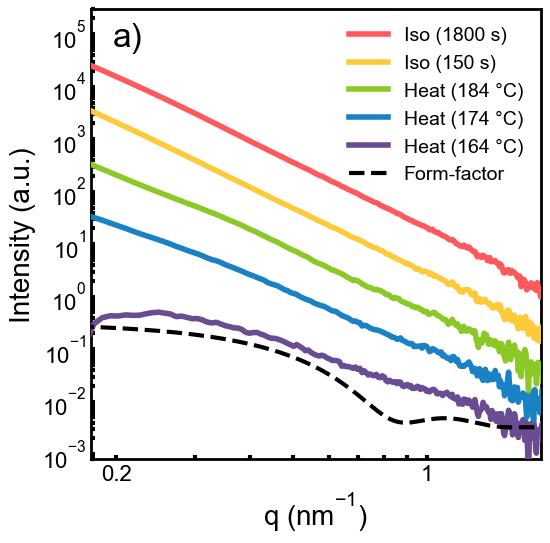

In [309]:
fig, ax = plt.subplots(figsize=(6, 6))

K = 1


ax.plot(q, (I_3_iso[59] -  K * I_3_heat[45]) * 16, linewidth=4, label='Iso (1800 s)', color='#ff595e', zorder=10)

ax.plot(q, (I_3_iso[5] -  K * I_3_heat[45]) * 4, linewidth=4, label='Iso (150 s)', color='#ffca3a', zorder=9)

ax.plot(q, (I_3_heat[80] - K * I_3_heat[45]), linewidth=4, label='Heat (184 °C)', color='#8ac926', zorder=8)

ax.plot(q, (I_3_heat[75] - K * I_3_heat[45]) / 4, linewidth=4, label='Heat (174 °C)',color='#1982c4', zorder=7)

ax.plot(q, (I_3_heat[70] - K * I_3_heat[45]) / 16, linewidth=4, label='Heat (164 °C)', color='#6a4c93', zorder=5)

ax.plot(q, 0.01*np.array(Polydisperse_spheres(q, 1e-2, 5, 0.1, 3e-1)), color='black', label='Form-factor', linewidth=3, linestyle='--', zorder=30)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.175, 1.8)
ax.set_ylim(0.8e-3, 3e5)
ax.set_xticks([0.2, 1])
ax.set_xticklabels(['0.2', '1'])

# Легенда
ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
    
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.text(0.05, 0.97, 'a)', transform=ax.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left', zorder=30)

ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.savefig(r'E:\Nps Cu\Figures\Fig2_a.png', dpi=300, bbox_inches='tight', transparent=True)

# Final 

##### XRD phases

In [5]:
lmbda = 1.5406e-1
# theta_array_Cu = [43.34, 50.46, 74.14, 89.93,]
# theta_array_Cu2O = [36.33, 42.21, 61.28, ]
# theta_array_CuO = [ 38.86, 39.11, 48.92, 58.47, 61.7, 66.06]

theta_array_Cu = [43.34,  50.46]
theta_array_CuO = [ 38.86, ]
theta_array_Cu2O = [36.33, ]

q_array_Cu = 4*pi/lmbda*np.sin(np.deg2rad(np.array(theta_array_Cu)/2))
q_array_Cu2O = 4*pi/lmbda*np.sin(np.deg2rad(np.array(theta_array_Cu2O)/2))
q_array_CuO = 4*pi/lmbda*np.sin(np.deg2rad(np.array(theta_array_CuO)/2))

##### Cu 0.5% 

In [6]:
Time_05_heat = Cu_05_heat.get_Time_profile()
Temp_05_heat = Cu_05_heat.get_T_profile()

Time_05_iso = Cu_05_iso.get_Time_profile() + Time_05_heat[-1]
Temp_05_iso = Cu_05_iso.get_T_profile()


Found 88 EDF files in SAXS
Found 66 EDF files in SAXS


Text(0, 0.5, 'Temperature')

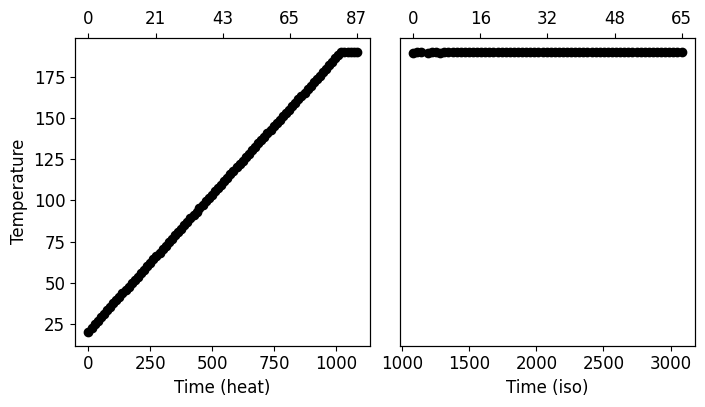

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
scatter1 = ax1.scatter(Time_05_heat, Temp_05_heat, color='black')
scatter2 = ax2.scatter(Time_05_iso, Temp_05_iso, color='black')

ax1_top = ax1.twiny()
ax2_top = ax2.twiny()

frames_heat = np.arange(len(Time_05_heat))
frames_iso = np.arange(len(Time_05_iso))

ax1_top.set_xlim(ax1.get_xlim())
ax2_top.set_xlim(ax2.get_xlim())

ax1_top.set_xticks(np.linspace(Time_05_heat[0], Time_05_heat[-1], 5))
ax1_top.set_xticklabels([f'{int(i)}' for i in np.linspace(0, len(Time_05_heat)-1, 5)])

ax2_top.set_xticks(np.linspace(Time_05_iso[0], Time_05_iso[-1], 5))
ax2_top.set_xticklabels([f'{int(i)}' for i in np.linspace(0, len(Time_05_iso)-1, 5)])

plt.subplots_adjust(wspace=0.1)


ax1.tick_params(right=False)
ax2.tick_params(left=False)

ax1.set_xlabel('Time (heat)')
ax2.set_xlabel('Time (iso)')
ax1.set_ylabel('Temperature')

##### Cu 3%

In [8]:
Time_3_heat = Cu_3_heat.get_Time_profile()
Temp_3_heat = Cu_3_heat.get_T_profile()

Time_3_iso = Cu_3_iso.get_Time_profile() + Time_3_heat[-1]
Temp_3_iso = Cu_3_iso.get_T_profile()


Found 89 EDF files in SAXS
Found 60 EDF files in SAXS


Text(0, 0.5, 'Temperature')

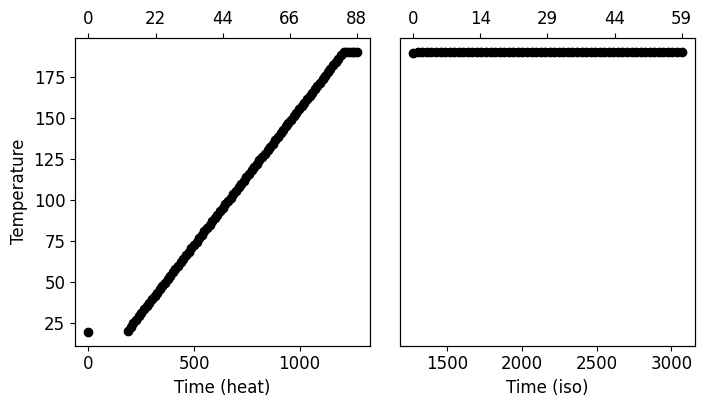

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
scatter1 = ax1.scatter(Time_3_heat, Temp_3_heat, color='black')
scatter2 = ax2.scatter(Time_3_iso, Temp_3_iso, color='black')

ax1_top = ax1.twiny()
ax2_top = ax2.twiny()

frames_heat = np.arange(len(Time_3_heat))
frames_iso = np.arange(len(Time_3_iso))

ax1_top.set_xlim(ax1.get_xlim())
ax2_top.set_xlim(ax2.get_xlim())

ax1_top.set_xticks(np.linspace(Time_3_heat[0], Time_3_heat[-1], 5))
ax1_top.set_xticklabels([f'{int(i)}' for i in np.linspace(0, len(Time_3_heat)-1, 5)])

ax2_top.set_xticks(np.linspace(Time_3_iso[0], Time_3_iso[-1], 5))
ax2_top.set_xticklabels([f'{int(i)}' for i in np.linspace(0, len(Time_3_iso)-1, 5)])

plt.subplots_adjust(wspace=0.1)


ax1.tick_params(right=False)
ax2.tick_params(left=False)

ax1.set_xlabel('Time (heat)')
ax2.set_xlabel('Time (iso)')
ax1.set_ylabel('Temperature')

##### SAXS Analysis

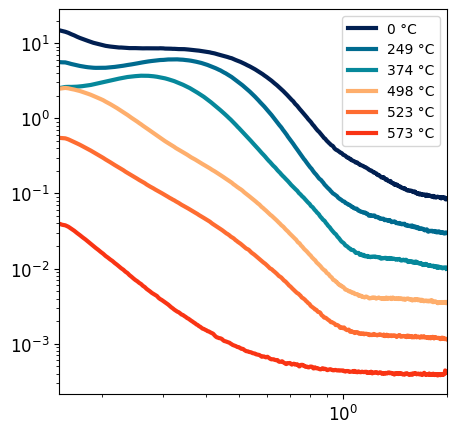

In [11]:
plt.figure(figsize=(5,5))

index = [0,  20,  30, 40, 42,  46]
colors = ['#011f51','#006b8f','#06889b','#feae6c','#fe6c31','#f93414']
coef = [1, 1/3, 1/9, 1/27, 1/81, 1/243, 1/64, 1/128]
width = 3

k = 0
for i in index:
    q, I = Cu_05_heat.get_1d_SAXS(i)
    #norm_saxs(q_saxs, I)
    plt.plot(q, I*coef[k], 
             label=str(Time_05_heat[i])+' °C', 
             linewidth=width, 
             color=colors[k]
            )
    k += 1
plt.xlim(.15, 2)
plt.semilogx()
plt.semilogy()
plt.legend(fontsize=10)
plt.show()

[]

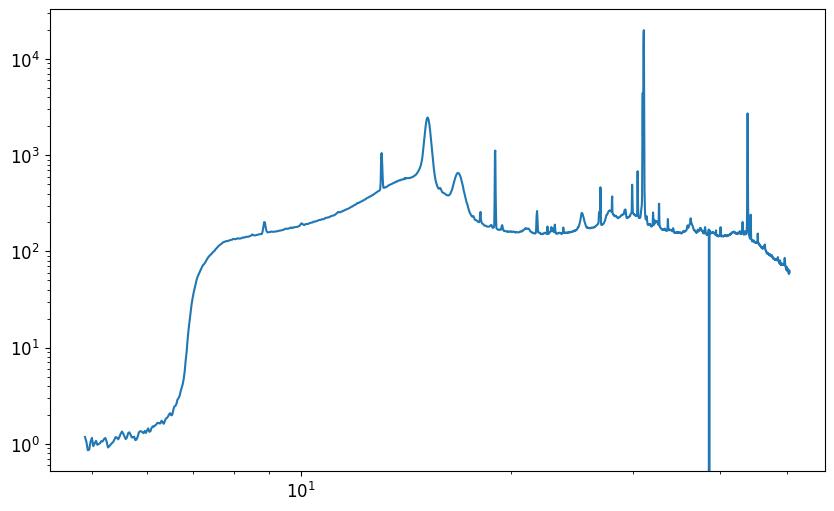

In [33]:
q, I = Cu_05_heat.get_1d_WAXS()
plt.plot(q, I)
plt.semilogy()
plt.semilogx()

In [31]:
q[39]

np.float64(0.12715503758812358)

##### XRD analysis


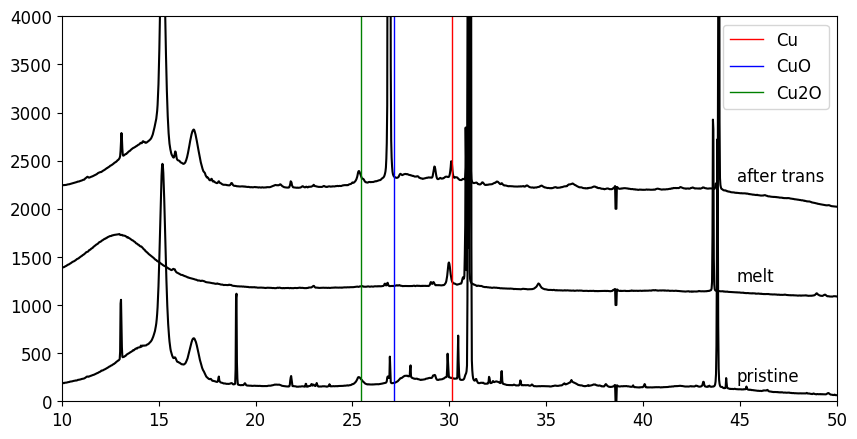

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

q, I = Cu_05_heat.get_1d_WAXS(0)
plt.plot(q, I, color='black')

q, I = Cu_05_iso.get_1d_WAXS(50)
plt.plot(q, I + 1000, color='black')

q, I = Cu_05_after.get_1d_WAXS(5)
plt.plot(q, I + 2000, color='black')



plt.ylim(0, 4000)
plt.xlim(10, 50)

# ax.axvline(x=q_array_Cu[0], color='red', linewidth=1, label='Cu' )
# ax.axvline(x=q_array_CuO[2], color='blue', linewidth=1, label='Cu' )
# ax.axvline(x=q_array_Cu2O[0], color='green', linewidth=1, label='Cu' )

for hkl in q_array_Cu:
    ax.axvline(x=hkl, color='red', linewidth=1, label='Cu' )

for hkl in q_array_CuO:
    ax.axvline(x=hkl, color='blue', linewidth=1, label='CuO')

for hkl in q_array_Cu2O:
    ax.axvline(x=hkl, color='green', linewidth=1, label='Cu2O')
    
fig.text(0.8, 0.15, 'pristine' )
fig.text(0.8, 0.35, 'melt' )
fig.text(0.8, 0.55, 'after trans' )

plt.legend()

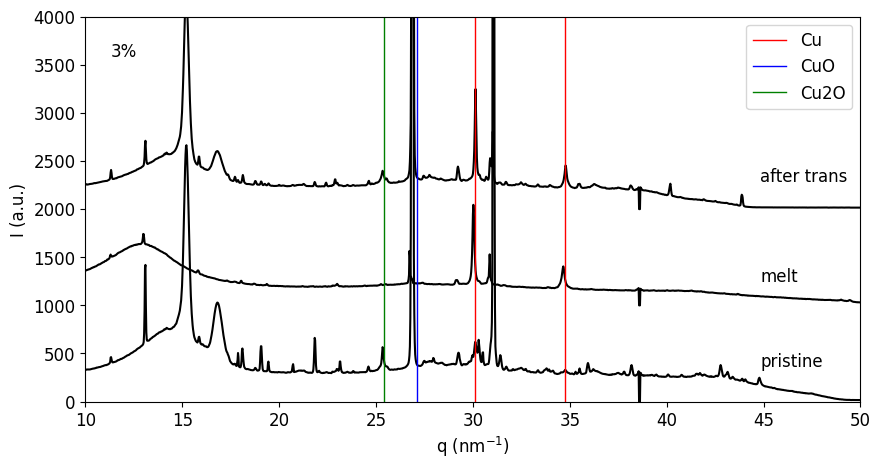

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

q, I = Cu_3_heat.get_1d_WAXS(0)
plt.plot(q, I, color='black')

q, I = Cu_3_iso.get_1d_WAXS(20)
plt.plot(q, I + 1000, color='black')

q, I = Cu_3_after.get_1d_WAXS(1)
plt.plot(q, I + 2000, color='black')



plt.ylim(0, 4000)
plt.xlim(10, 50)

# ax.axvline(x=q_array_Cu[0], color='red', linewidth=1, label='Cu' )
# ax.axvline(x=q_array_CuO[2], color='blue', linewidth=1, label='Cu' )
# ax.axvline(x=q_array_Cu2O[0], color='green', linewidth=1, label='Cu' )

flag = 0
for hkl in q_array_Cu:
    if flag == 0:
        ax.axvline(x=hkl, color='red', linewidth=1, label='Cu' )
        flag += 1
    else:
        ax.axvline(x=hkl, color='red', linewidth=1 )
    
for hkl in q_array_CuO:
    ax.axvline(x=hkl, color='blue', linewidth=1, label='CuO')

for hkl in q_array_Cu2O:
    ax.axvline(x=hkl, color='green', linewidth=1, label='Cu2O')
    
fig.text(0.15, 0.8, '3%' )
fig.text(0.8, 0.18, 'pristine' )
fig.text(0.8, 0.35, 'melt' )
fig.text(0.8, 0.55, 'after trans' )

ax.set_xlabel('q (nm$^{-1}$)')
ax.set_ylabel('I (a.u.)')
plt.legend()

# Plots

In [10]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 20
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.tt'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

In [11]:
def Invariant(q, I):
    l = 0.15
    r = 1.5
    x = q[(q>l)*(q<r)]
    y = I[(q>l)*(q<r)]
    return np.trapz(y*x**2, x=x)

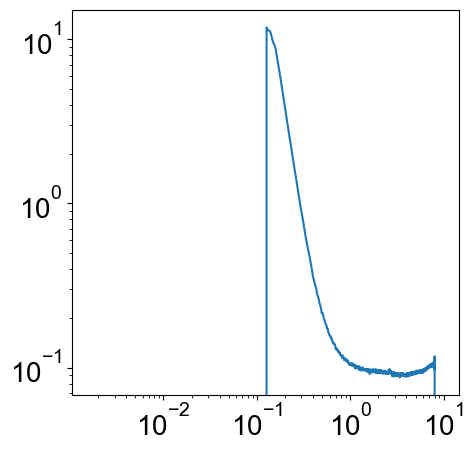

In [14]:
fig, ax = plt.subplots(figsize=(5,5))

q, I = Cu_05_heat.get_1d_SAXS(45)
ax.plot(q, I)

ax.set_xscale('log')
ax.set_yscale('log')
